In [1]:
#required packages
import sys
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb
import random as rd
import warnings
import tqdm
from tqdm import tqdm
import tabulate

import sklearn
from sklearn.decomposition import PCA
from google.colab import drive
from google.colab import files

#mount to gdrive
drive.mount('/content/gdrive')
gdrive_path = '/content/gdrive/MyDrive/REVEAL_UCSF_project/chemical_database_list'
gdrive_path2 = '/content/gdrive/MyDrive/REVEAL_UCSF_project/First400'
gdrive_path4 = '/content/gdrive/MyDrive/REVEAL_UCSF_project/chemical_database_list'

Mounted at /content/gdrive


In [2]:
!pip install rdkit
#install isospcpy
!pip install IsoSpecPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.1/152.1 kB 2.6 MB/s eta 0:00:00


In [3]:
from tqdm import tqdm
import tabulate
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
peakarea_path = [os.path.join(gdrive_path2, "pos_Area_1_2025_06_12_14_43_23_updated.csv")]
QACs_path = [os.path.join(gdrive_path2,'QACs_chemical_list_comptox_March09_updated.csv')]
QACs_path2 = [os.path.join(gdrive_path,'8QACs_chemical_list_comptox_with_istd_April19.csv')]  #with ISTD: D15-TPP

#load peak area
pos_peak_area = pd.read_csv(peakarea_path[0])
QACs_mz = pd.read_csv(QACs_path[0])
print(pos_peak_area.shape)
print(QACs_mz.shape)

# Function to calculate ppm difference
def ppm_difference(value1, value2):
    return abs(value1 - value2) / value1 * 1e6

(64004, 967)
(49, 16)


In [4]:
#exact mass search
targetmzdat_pos = QACs_mz.copy()
targetmzdat_pos['mz'] = targetmzdat_pos['Exact_mass']

ppm_threshold = 20
matched_rows_pos = []
matched_summary = []

# MS1 search and matching
for _, chem_row in tqdm(targetmzdat_pos.iterrows(), total=targetmzdat_pos.shape[0], desc="Matching compounds"):
    mw = chem_row['mz']
    # RT = chem_row['RT2']
    matches = pos_peak_area[pos_peak_area['Average Mz'].apply(lambda mz: ppm_difference(mz, mw) <= ppm_threshold)]
    #filter matches by RT differences = Average RT - RT2
    #matches = matches[matches['Average Rt(min)'].apply(lambda rt: abs(rt - RT) <= 0.8)]

    if not matches.empty:
        # Append the matches along with the corresponding compound information
        for _, match_row in matches.iterrows():
            matched_rows_pos.append({
                **match_row,
                'Matched Compound': chem_row['SMILES'],
                'MS_READY_SMILES': chem_row.get('MS_READY_SMILES', None),
                'DTXSID': chem_row.get('DTXSID', None),
                'InChiKey_original': chem_row.get('INCHIKEY', None),
                'MS_READY_FORMULA': chem_row.get('MS_READY_FORMULA', None),
                "Monoisotopic_mass_ready": chem_row.get('Exact_mass', None)
            })

# convert to data frame for data imputation
matched_peak_area_df_pos = pd.DataFrame(matched_rows_pos)

#output the matched peak area data
matched_peak_pos = matched_peak_area_df_pos.sort_values(by=['Average Rt(min)', 'Average Mz'])
#mutate feature_id columns by combing Average Mz and Average Rt(min)
matched_peak_pos['feature_id'] = matched_peak_pos['Average Mz'].astype(str) + '_' + matched_peak_pos['Average Rt(min)'].astype(str)
print(matched_peak_pos.shape)
print(matched_peak_pos.columns)

################################################output feature table##############################################################################################
# matched_peak_pos.to_csv(os.path.join(gdrive_path2,"matched_peak_area_database_pos_QACs_0309.csv"))
# summary_stats_df_pos = pd.DataFrame(matched_peak_pos)
# # summary_stats_df_pos.to_csv(os.path.join(gdrive_path2,'mathced_peaks_summary_forallsamples_pos_QACs_0309.csv')) #this is match for standards without RT

Matching compounds: 100%|██████████| 49/49 [00:01<00:00, 29.47it/s]


(231, 974)
Index(['Alignment ID', 'Average Rt(min)', 'Average Mz', 'Metabolite name',
       'Adduct type', 'Post curation result', 'Fill %', 'MS/MS assigned',
       'Reference RT', 'Reference m/z',
       ...
       'QC-ISTD CHECK_pos_batch20-pos', '1', '1.1', 'Matched Compound',
       'MS_READY_SMILES', 'DTXSID', 'InChiKey_original', 'MS_READY_FORMULA',
       'Monoisotopic_mass_ready', 'feature_id'],
      dtype='object', length=974)


In [5]:
meta_info = [os.path.join(gdrive_path2, 'pos_column2_manualupdate_withinjection.csv')]
meta_info = pd.read_csv(meta_info[0])
original_pos_peak_area  = matched_peak_pos.copy()

# --------------------------------------------------
# Step 2: batch-wise blank subtraction using meta_info
# --------------------------------------------------
# meta_info must contain: Sample, Batch, Injection_order
required_meta_cols = ['Sample', 'Batch', 'Injection_order']
meta_info['Sample'] = meta_info['Sample'].astype(str)
meta_info['Batch'] = meta_info['Batch'].astype(str)

# identify BH samples and DI blanks from meta_info
bh_samples = meta_info.loc[meta_info['Sample'].str.startswith('BH'), 'Sample'].tolist()
di_blanks = meta_info.loc[meta_info['Sample'].str.startswith('DI'), 'Sample'].tolist()

# keep only columns that actually exist in the peak area table
bh_samples = [c for c in bh_samples if c in original_pos_peak_area.columns]
di_blanks = [c for c in di_blanks if c in original_pos_peak_area.columns]

# convert sample columns to numeric
sample_cols = bh_samples + di_blanks
for col in sample_cols:
    original_pos_peak_area[col] = pd.to_numeric(original_pos_peak_area[col], errors='coerce')

# preserve metadata columns
non_sample_cols = [c for c in original_pos_peak_area.columns if c not in sample_cols]
corrected_pos_peak_area = original_pos_peak_area.copy()

# subtract mean DI blank within each batch from each BH sample in the same batch
for batch_name, batch_df in meta_info.groupby('Batch'):
    batch_samples = batch_df['Sample'].tolist()
    batch_bh = [s for s in batch_samples if s.startswith('BH') and s in corrected_pos_peak_area.columns]
    batch_di = [s for s in batch_samples if s.startswith('DI') and s in corrected_pos_peak_area.columns]
    # row-wise mean blank for this batchyyy
    batch_blank_mean = corrected_pos_peak_area[batch_di].mean(axis=1)
    # subtract from each BH sample in this batch
    corrected_pos_peak_area[batch_bh] = corrected_pos_peak_area[batch_bh].sub(batch_blank_mean, axis=0)

# set negative values to 0
corrected_pos_peak_area[bh_samples] = corrected_pos_peak_area[bh_samples].clip(lower=0)
print(f'corrected_pos_peak_area shape: {corrected_pos_peak_area.shape}')


#get BH sample columns and caluclate detection frequency
bh_columns = [col for col in corrected_pos_peak_area.columns if col.startswith('BH')]
grouped_samples = {}
for col in bh_columns:
    # Split at the first underscore and remove ANY trailing/leading spaces
    base_col = col.split('_')[0].strip()
    if base_col not in grouped_samples:
        grouped_samples[base_col] = []
    grouped_samples[base_col].append(col)

mean_columns = {}
for base_col, replicate_cols in grouped_samples.items():
    # Calculate the mean across the replicates for this specific sample
    mean_columns[base_col] = corrected_pos_peak_area[replicate_cols].mean(axis=1)

mean_columns_df = pd.DataFrame(mean_columns)

# Drop the old messy columns and attach the newly averaged ones
corrected_average_peak_area = corrected_pos_peak_area.drop(columns=bh_columns)
corrected_average_peak_area = pd.concat([corrected_average_peak_area, mean_columns_df], axis=1)
print(f"Total columns starting with 'BH' now attached to df: {len([col for col in corrected_average_peak_area.columns if col.startswith('BH')])}")

bh_avg_columns = [col for col in corrected_average_peak_area.columns if col.startswith('BH')]
#calculate the detection frequency for each row -- each feature
    #detection frequency = number of peak area >= 1000 / totoal number of sample columns *100
corrected_average_peak_area['Detection frequency'] = (
    corrected_average_peak_area[bh_avg_columns]
    .ge(5000)
    .sum(axis=1)
    .div(len(bh_avg_columns))
    .mul(100)
)

#mutate a column 'feature_id' = str(Average Mz)_str(Average Rt(min))
corrected_average_peak_area['feature_id'] = corrected_average_peak_area['Average Mz'].astype(str) + '_' + corrected_average_peak_area['Average Rt(min)'].astype(str)

#summary of the detection frequency value and print it by tabulate.tabulate
print(corrected_average_peak_area['Detection frequency'].describe())

#output corrected average peak area table for downstream anlaysis
corrected_average_peak_area.to_csv(os.path.join(gdrive_path2,"corrected_average_peak_area_pos_QACs_0505.csv"))
print(corrected_average_peak_area.shape)

corrected_pos_peak_area shape: (231, 974)
Total columns starting with 'BH' now attached to df: 400
count    231.000000
mean      22.612554
std       26.707856
min        0.000000
25%        3.250000
50%       12.500000
75%       31.375000
max      100.000000
Name: Detection frequency, dtype: float64
(231, 575)


In [6]:
#data structure of corrected average_peak_area
#get peak normalized for concentration estimation
QACs_mz2 = pd.read_csv(QACs_path2[0])
#define RT threshold
RT_threshold = 0.5

#make an empty dataframe to append the matches rows, make sure the intial dataframe has the same columns as the corrected_average_peak_area
matched_target = pd.DataFrame(columns=corrected_average_peak_area.columns)
#loop over QACS_mz2, based on QACS_mz2, extract rows of peak area from corrected_average peak area based on DTXSID and RT match
for _, row in QACs_mz2.iterrows():
    DTXSID = row['DTXSID']
    RT = row['RT']
    matches = corrected_average_peak_area[(corrected_average_peak_area['DTXSID'] == DTXSID) & (corrected_average_peak_area['Average Rt(min)'] <= RT + RT_threshold) & (corrected_average_peak_area['Average Rt(min)'] >= RT - RT_threshold)]
    print(f'number of matches:{matches.shape}')
    #if multiple rows, calulate the average peak area temperory from column starts with 'BH' and remain the row with the maximum avearge peak area and save it as the matches at the end
    if matches.shape[0] > 1:
        matches = matches.loc[matches[matches.columns[matches.columns.str.startswith('BH')]].mean(axis=1).idxmax()]
        matches = pd.DataFrame([matches])
    #add the matched rows to the results
    matched_target = pd.concat([matched_target, matches])

#print the matched dataframe
print(matched_target.shape)

#now caluclate the detection frequency for sample columns: number of sample columns with peak area >= peak threshold / total number of sample columns *100, sample columns: column name starts with 'BH'
sample_cols = [col for col in matched_target.columns if col.startswith('BH')]
matched_target['Detection frequency by peak area'] = (
    matched_target[sample_cols]
    .ge(5000)
    .sum(axis=1)
    .div(len(sample_cols))
    .mul(100)
)

#now print the table of avearge RT avearg MZ, DTXSID, and detection frequency by peak area
print(tabulate.tabulate(matched_target[['Average Rt(min)', 'Average Mz', 'DTXSID', 'Detection frequency by peak area']], headers='keys', tablefmt='psql', showindex=False))

#drop the row with DTSC DTXSID00978073 AND DTXSID4020325
#output the matched_target feature tables
matched_target.to_csv(os.path.join(gdrive_path2,"8QACs_matched_target_blanksub_avg_peakarea_0521.csv"))

number of matches:(2, 575)
number of matches:(5, 575)
number of matches:(7, 575)
number of matches:(4, 575)
number of matches:(3, 575)
number of matches:(5, 575)
number of matches:(8, 575)
number of matches:(6, 575)
number of matches:(0, 575)
(8, 575)
+-------------------+--------------+----------------+------------------------------------+
|   Average Rt(min) |   Average Mz | DTXSID         |   Detection frequency by peak area |
|-------------------+--------------+----------------+------------------------------------|
|             1.022 |      146.117 | DTXSID00978073 |                              82.75 |
|             0.981 |      104.107 | DTXSID4020325  |                             100    |
|            15.087 |      284.331 | DTXSID6026901  |                              36    |
|            11.255 |      228.269 | DTXSID1026900  |                              19.25 |
|            16.767 |      388.394 | DTXSID2025139  |                              10.5  |
|            15.602 

/tmp/ipykernel_3820/556538799.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  matched_target = pd.concat([matched_target, matches])


In [8]:
################################now get the ISTD peak area acorss all samples#########################
#select ISTD row in DTXSID column
QACs_mz2 = pd.read_csv(QACs_path2[0])
targetmzdat = QACs_mz2[QACs_mz2['DTXSID'].str.contains('ISTD')].copy()
targetmzdat['mz'] = targetmzdat['Exact_mass']
print(tabulate.tabulate(targetmzdat, headers='keys', tablefmt='psql', showindex=False))

ppm_threshold = 10
RT_threshold = 0.5
matched_rows_pos = []

# MS1 search and RT matching
for _, chem_row in tqdm(targetmzdat.iterrows(), total=targetmzdat.shape[0], desc="Matching compounds"):
    mw = chem_row['mz']
    RT = chem_row['RT']
    matches = pos_peak_area[pos_peak_area['Average Mz'].apply(lambda mz: ppm_difference(mz, mw) <= ppm_threshold)]
    # filter matches by RT differences = Average RT - RT2
    matches = matches[matches['Average Rt(min)'].apply(lambda rt: abs(rt - RT) <= RT_threshold)]

    if not matches.empty:
        # Append the matches along with the corresponding compound information
        for _, match_row in matches.iterrows():
            matched_rows_pos.append({
                **match_row,
                'Matched Compound': chem_row['SMILES'],
                'MS_READY_SMILES': chem_row.get('MS_READY_SMILES', None),
                'DTXSID': chem_row.get('DTXSID', None),
                'InChiKey_original': chem_row.get('INCHIKEY', None),
                'MS_READY_FORMULA': chem_row.get('MS_READY_FORMULA', None),
                "Monoisotopic_mass_ready": chem_row.get('Exact_mass', None)
            })

# convert to data frame for data imputation
matched_peak_ISTD = pd.DataFrame(matched_rows_pos)
print(matched_peak_ISTD.shape)
#if multiple rows return, remain the rows with the maximum mean peak area across all columns startswith 'BH'
# if matched_peak_ISTD.shape[0] > 1:
#     matched_peak_ISTD = matched_peak_ISTD.loc[matched_peak_ISTD[matched_peak_ISTD.columns[matched_peak_ISTD.columns.str.startswith('BH')]].mean(axis=1).idxmax()]
#     matched_peak_ISTD = pd.DataFrame([matched_peak_ISTD])

#mutate feature_id
matched_peak_ISTD['feature_id'] = matched_peak_ISTD['Average Mz'].astype(str) + '_' + matched_peak_ISTD['Average Rt(min)'].astype(str)

#get the mean value of each sample columns and return the mean value for each sample column as the representation
  #get BH sample columns
bh_columns = [col for col in matched_peak_ISTD.columns if col.startswith('BH')]
grouped_samples = {}
for col in bh_columns:
    # Split at the first underscore and remove ANY trailing/leading spaces
    base_col = col.split('_')[0].strip()
    if base_col not in grouped_samples:
        grouped_samples[base_col] = []
    grouped_samples[base_col].append(col)

mean_columns = {}
for base_col, replicate_cols in grouped_samples.items():
    # Calculate the mean across the replicates for this specific sample
    mean_columns[base_col] = matched_peak_ISTD[replicate_cols].mean(axis=1)
mean_columns_df = pd.DataFrame(mean_columns)
# Drop the old messy columns and attach the newly averaged ones
matched_peak_ISTD_avg = matched_peak_ISTD.drop(columns=bh_columns)
matched_peak_ISTD_avg = pd.concat([matched_peak_ISTD_avg, mean_columns_df], axis=1)


# ===============================================================================
# Step 7. For each matched chemical, extract maximum peak abundance per sample
# ===============================================================================
group_col = "DTXSID"
dtxsid = 'ISTD'
averaged_bh_cols = [col for col in matched_peak_ISTD_avg.columns if col.startswith('BH')]
# Convert averaged sample columns to numeric
for col in averaged_bh_cols:
    matched_peak_ISTD_avg[col] = pd.to_numeric(
        matched_peak_ISTD_avg[col],
        errors="coerce")
output_records = []
for dtxsid, group_df in matched_peak_ISTD_avg.groupby(group_col, dropna=False):
    record = {}
    # Save only DTXSID for compound annotation
    record["DTXSID"] = dtxsid
    # For each sample, find max abundance across matched features for this DTXSID
    for sample_col in averaged_bh_cols:
        record[sample_col] = group_df[sample_col].max(skipna=True)
    # Representative feature:
    # use the feature row with the highest total abundance across all averaged BH samples
    tmp = group_df.copy()
    tmp["_total_abundance"] = tmp[averaged_bh_cols].sum(axis=1, skipna=True)
    if tmp["_total_abundance"].notna().any():
        best_idx = tmp["_total_abundance"].idxmax()
        best_row = tmp.loc[best_idx]
    else:
        best_row = group_df.iloc[0]

    # Save only Average RT and Average Mz as annotation
    record["Average Rt(min)"] = best_row["Average Rt(min)"]
    record["Average Mz"] = best_row["Average Mz"]
    output_records.append(record)
matched_peak_ISTD_max = pd.DataFrame(output_records)

# Final output columns:
# DTXSID, Average Rt(min), Average Mz, sample columns
front_cols = ["DTXSID","Average Rt(min)","Average Mz"]
matched_peak_ISTD_max = matched_peak_ISTD_max[front_cols + averaged_bh_cols]

print(f"matched_peak_ISTD_max shape: {matched_peak_ISTD_max.shape}")
print(tabulate.tabulate(matched_peak_ISTD_max.head(), headers="keys", tablefmt="psql", showindex=False))


sample_cols = [col for col in matched_peak_ISTD_max.columns if col.startswith('BH')]
matched_peak_ISTD_max['Detection frequency by peak area'] = (
    matched_peak_ISTD_max[sample_cols]
    .ge(5000)
    .sum(axis=1)
    .div(len(sample_cols))
    .mul(100)
)

#calculate mean
print(matched_peak_ISTD_max.shape)

+---------+---------------------+--------------+-------+-------+------------+----------+-------------+----------+---------+------------------+----------+--------------------------+---------+
| Name    |   MOLECULAR_FORMULA |   Exact_mass |    RT |   CAS | Synonyms   | DTXSID   |   IUPACname |   DTXCID |   CASRN |   PREFERRED_NAME |   SMILES |   MONOISOTOPIC_MASS_mass |      mz |
|---------+---------------------+--------------+-------+-------+------------+----------+-------------+----------+---------+------------------+----------+--------------------------+---------|
| D15-TPP |                 nan |      342.172 | 11.74 |   nan | ISTD       | ISTD     |         nan |      nan |     nan |              nan |      nan |                      nan | 342.172 |
+---------+---------------------+--------------+-------+-------+------------+----------+-------------+----------+---------+------------------+----------+--------------------------+---------+


Matching compounds: 100%|██████████| 1/1 [00:00<00:00, 17.27it/s]

(7, 973)


matched_peak_ISTD_max shape: (1, 403)
+----------+-------------------+--------------+-------------+-------------+-------------+-------------+------------+-------------+-------------+-------------+-------------+-------------+-------------+------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-----------+-------------+-------------+-------------+-------------+-----------+-------------+------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+-------------+------------+-------------

In [10]:
###################row bind ISTD with the QAC rows and then do normalization: sample area of each QACs/ISTD######
#combine the matched_peak_ISTD_avg and matched_peak_pos by row
print(matched_peak_ISTD_max.shape)
print(matched_target.shape)
QAC_ISTD_matches = pd.concat([matched_peak_ISTD_max, matched_target], ignore_index=True)

#normalized the bh_columns peak area by the ISTD peak area
bh_columns = [col for col in QAC_ISTD_matches.columns if col.startswith('BH')]

istd_id = "ISTD"
QAC_ISTD_matches_norm = QAC_ISTD_matches.copy()
# Make sure averaged BH columns are numeric
for col in bh_columns:
    QAC_ISTD_matches_norm[col] = pd.to_numeric(
        QAC_ISTD_matches_norm[col],
        errors="coerce"
    )
# Find ISTD row
istd_rows = QAC_ISTD_matches_norm[
    QAC_ISTD_matches_norm["DTXSID"].astype(str).eq(str(istd_id))
].copy()
if istd_rows.empty:
    raise ValueError(
        f"No ISTD row found in compound_max_peak_pos using DTXSID == {istd_id}. "
        "Please check the ISTD label in the DTXSID column."
    )
if istd_rows.shape[0] > 1:
    print(f"Warning: multiple ISTD rows found: {istd_rows.shape[0]}. Using the first ISTD row.")
istd_row = istd_rows.iloc[0]
# Extract ISTD peak area for each averaged BH sample column
istd_values = pd.to_numeric(
    istd_row[bh_columns],
    errors="coerce"
).replace(0, np.nan)

# Normalize each averaged BH sample column by its corresponding ISTD abundance
QAC_ISTD_matches_norm[bh_columns] = QAC_ISTD_matches_norm[
    bh_columns
].div(
    istd_values,
    axis=1
)

print(f"QAC_ISTD_matches_norm shape: {QAC_ISTD_matches_norm.shape}")
print(tabulate.tabulate(QAC_ISTD_matches_norm, headers="keys", tablefmt="psql", showindex=False))
#drop ISTD row
QAC_ISTD_matches_norm = QAC_ISTD_matches_norm[~QAC_ISTD_matches_norm["DTXSID"].astype(str).eq(str(istd_id))]
#output the data results to 8QACs_normalized_peak_area_withISTD_13052026.csv
# QAC_ISTD_matches_norm.to_csv(os.path.join(gdrive_path2,"8QACs_normalized_peak_area_withISTD_13052026.csv"))

(1, 404)
(8, 576)
QAC_ISTD_matches_norm shape: (9, 576)
+----------------+-------------------+--------------+------------+------------+------------+------------+-------------+------------+-------------+------------+------------+------------+------------+------------+------------+-------------+-----------+-------------+------------+------------+-----------+-------------+-------------+------------+-------------+-------------+-------------+------------+------------+-------------+-------------+------------+------------+------------+------------+-------------+-------------+-------------+-------------+-------------+-------------+------------+------------+-------------+-------------+------------+------------+-------------+-------------+-------------+-------------+------------+-------------+-------------+------------+------------+-------------+-------------+-------------+-------------+-------------+------------+------------+-------------+-------------+-------------+-------------+-------------+

In [11]:
####################################################################################################
# QAC isotope-pattern scoring for matched_peak_pos
# Assumption:
#   QAC compounds are already MS-ready for [M]+
#   observed m/z ≈ Monoisotopic_mass_ready
#   isotope formula = MS_READY_FORMULA
####################################################################################################
from IsoSpecPy import IsoTotalProb
import re

# ================================================================================================
# 1. Input
# ================================================================================================

df = matched_peak_pos.copy()

mz_col = "Average Mz"
iso_col = "MS1 isotopic spectrum"
formula_col = "MS_READY_FORMULA"
mass_col = "Monoisotopic_mass_ready"

df[mz_col] = df[mz_col].astype(float)
df[mass_col] = df[mass_col].astype(float)


# ================================================================================================
# 2. Parse MS-DIAL isotope column
# ================================================================================================

def parse_msdial_isotope_spectrum(spectrum_str):
    if pd.isna(spectrum_str):
        return None, None

    mzs = []
    intensities = []

    try:
        for pair in str(spectrum_str).strip().split():
            if ":" not in pair:
                continue

            mz, inten = pair.split(":")
            mzs.append(float(mz))
            intensities.append(float(inten))

        if len(mzs) == 0:
            return None, None

        mzs = np.array(mzs, dtype=float)
        intensities = np.array(intensities, dtype=float)

        if intensities.max() <= 0:
            return None, None

        intensities_norm = intensities / intensities.max() * 100.0

        return mzs, intensities_norm

    except Exception:
        return None, None


# ================================================================================================
# 3. Formula cleaning
# ================================================================================================

def clean_formula(formula):
    if not isinstance(formula, str):
        return None

    formula = formula.strip()
    formula = formula.replace("+", "")
    formula = formula.replace("-", "")
    formula = re.sub(r"\s+", "", formula)

    return formula if formula != "" else None


# ================================================================================================
# 4. Generate theoretical isotope pattern for QAC [M]+
# ================================================================================================

def theoretical_isotope_pattern_qac(
    formula,
    mono_mz=None,
    prob_to_cover=0.999,
    max_peaks=3
):
    formula_clean = clean_formula(formula)

    if formula_clean is None:
        return None, None

    iso = IsoTotalProb(formula=formula_clean, prob_to_cover=prob_to_cover)
    iso_list = list(iso)

    if len(iso_list) == 0:
        return None, None

    theo_mz = np.array([m for m, p in iso_list], dtype=float)
    theo_prob = np.array([p for m, p in iso_list], dtype=float)

    order = np.argsort(theo_mz)
    theo_mz = theo_mz[order]
    theo_prob = theo_prob[order]

    theo_mz = theo_mz[:max_peaks]
    theo_prob = theo_prob[:max_peaks]

    if theo_prob.max() <= 0:
        return None, None

    theo_int = theo_prob / theo_prob.max() * 100.0

    # Align theoretical M peak to your cleaned exact mass column
    if mono_mz is not None and len(theo_mz) > 0:
        shift = float(mono_mz) - theo_mz[0]
        theo_mz = theo_mz + shift

    return theo_mz, theo_int


# ================================================================================================
# 5. Isotope cosine scoring functions
# ================================================================================================

def cosine_score(obs_vec, theo_vec):
    obs_vec = np.array(obs_vec, dtype=float)
    theo_vec = np.array(theo_vec, dtype=float)

    if np.linalg.norm(obs_vec) == 0 or np.linalg.norm(theo_vec) == 0:
        return np.nan

    return float(
        np.dot(obs_vec, theo_vec)
        / (np.linalg.norm(obs_vec) * np.linalg.norm(theo_vec))
    )


def score_isotope_pattern(
    obs_mz,
    obs_int,
    theo_mz,
    theo_int,
    ppm_tol=10,
    require_mono_peak=True
):
    """
    Match theoretical isotope peaks to observed MS-DIAL isotope peaks.
    Missing observed peaks are assigned intensity 0.
    """
    if obs_mz is None or obs_int is None or theo_mz is None or theo_int is None:
        return np.nan, None, None

    obs_mz = np.array(obs_mz, dtype=float)
    obs_int = np.array(obs_int, dtype=float)
    theo_mz = np.array(theo_mz, dtype=float)
    theo_int = np.array(theo_int, dtype=float)

    matched_obs = []
    matched_theo = []

    for mz_t, int_t in zip(theo_mz, theo_int):
        ppm_diff = np.abs(obs_mz - mz_t) / mz_t * 1e6

        if len(ppm_diff) == 0:
            matched_obs.append(0.0)
            matched_theo.append(float(int_t))
            continue

        best_idx = np.argmin(ppm_diff)

        if ppm_diff[best_idx] <= ppm_tol:
            matched_obs.append(float(obs_int[best_idx]))
        else:
            matched_obs.append(0.0)

        matched_theo.append(float(int_t))

    matched_obs = np.array(matched_obs)
    matched_theo = np.array(matched_theo)

    if require_mono_peak and matched_obs[0] == 0:
        return np.nan, matched_obs, matched_theo

    score = cosine_score(matched_obs, matched_theo)

    return score, matched_obs, matched_theo


# ================================================================================================
# 6. Apply isotope scoring row-by-row
# ================================================================================================

ppm_tol_iso = 10
max_iso_peaks = 3

iso_scores = []
mass_ppm_errors = []

obs_iso_mz_list = []
obs_iso_int_list = []
theo_iso_mz_list = []
theo_iso_int_list = []
matched_obs_int_list = []
matched_theo_int_list = []

for _, row in df.iterrows():

    obs_mz = float(row[mz_col])
    candidate_mass = float(row[mass_col])
    formula = row[formula_col]

    obs_iso_mz, obs_iso_int = parse_msdial_isotope_spectrum(row[iso_col])

    theo_iso_mz, theo_iso_int = theoretical_isotope_pattern_qac(
        formula=formula,
        mono_mz=candidate_mass,
        prob_to_cover=0.999,
        max_peaks=max_iso_peaks
    )

    iso_score, matched_obs_int, matched_theo_int = score_isotope_pattern(
        obs_mz=obs_iso_mz,
        obs_int=obs_iso_int,
        theo_mz=theo_iso_mz,
        theo_int=theo_iso_int,
        ppm_tol=ppm_tol_iso,
        require_mono_peak=True
    )

    mass_ppm_error = abs(obs_mz - candidate_mass) / candidate_mass * 1e6

    iso_scores.append(iso_score)
    mass_ppm_errors.append(mass_ppm_error)

    obs_iso_mz_list.append(obs_iso_mz.tolist() if isinstance(obs_iso_mz, np.ndarray) else None)
    obs_iso_int_list.append(obs_iso_int.tolist() if isinstance(obs_iso_int, np.ndarray) else None)
    theo_iso_mz_list.append(theo_iso_mz.tolist() if isinstance(theo_iso_mz, np.ndarray) else None)
    theo_iso_int_list.append(theo_iso_int.tolist() if isinstance(theo_iso_int, np.ndarray) else None)

    matched_obs_int_list.append(
        matched_obs_int.tolist() if isinstance(matched_obs_int, np.ndarray) else None
    )
    matched_theo_int_list.append(
        matched_theo_int.tolist() if isinstance(matched_theo_int, np.ndarray) else None
    )


# ================================================================================================
# 7. Add results back to the same table
# ================================================================================================

df["qac_isotope_cosine_score"] = iso_scores
df["qac_mass_ppm_error"] = mass_ppm_errors

df["obs_iso_mz"] = obs_iso_mz_list
df["obs_iso_int_norm"] = obs_iso_int_list
df["theoretical_iso_mz"] = theo_iso_mz_list
df["theoretical_iso_int_norm"] = theo_iso_int_list
df["matched_obs_iso_int"] = matched_obs_int_list
df["matched_theoretical_iso_int"] = matched_theo_int_list


# ================================================================================================
# 8. Optional ranking per feature
# ================================================================================================

df["qac_combined_ms1_score"] = (
    0.7 * df["qac_isotope_cosine_score"].fillna(0)
    + 0.3 * (1 - (df["qac_mass_ppm_error"] / 5).clip(lower=0, upper=1))
)

df = df.sort_values(
    by=["feature_id", "qac_combined_ms1_score", "qac_isotope_cosine_score"],
    ascending=[True, False, False]
).reset_index(drop=True)


# ================================================================================================
# 9. Output
# ================================================================================================

matched_peak_pos_iso_scored = df.copy()

print("Done.")
print(f"Rows scored: {len(matched_peak_pos_iso_scored)}")

print(
    tabulate.tabulate(
        matched_peak_pos_iso_scored[
            [
                "feature_id",
                'DTXSID',
                mz_col,
                "Matched Compound",
                formula_col,
                mass_col,
                "qac_mass_ppm_error",
                "qac_isotope_cosine_score",
                "qac_combined_ms1_score"
            ]
        ].head(20),
        headers="keys",
        tablefmt="psql",
        showindex=False
    )
)

# Optional save
matched_peak_pos_iso_scored.to_csv(
    os.path.join(gdrive_path2, "matched_peak_pos_with_qac_isotope_scores.csv"),
    index=False)

#attach the qac_isotope_cosine_score to the two results: QAC_ISTD_matches_norm and corrected_average_peak_area by matching against the feature_id and DTXSID
QAC_ISTD_matches_norm = QAC_ISTD_matches_norm.merge(matched_peak_pos_iso_scored[['feature_id', 'DTXSID', 'qac_isotope_cosine_score']], on=['feature_id', 'DTXSID'], how='left')
QAC_ISTD_matches_norm.to_csv(os.path.join(gdrive_path2,"QAC_ISTD_matches_norm_with_qac_isotope_scores.csv"))
QAC_ISTD_matches_norm.to_csv(os.path.join(gdrive_path2,"8QACs_normalized_peak_area_withISTD_with_qac_isotope_scores_13052026.csv"))
corrected_average_peak_area = corrected_average_peak_area.merge(matched_peak_pos_iso_scored[['feature_id', 'DTXSID', 'qac_isotope_cosine_score']], on=['feature_id', 'DTXSID'], how='left')
corrected_average_peak_area.to_csv(os.path.join(gdrive_path2,"corrected_average_peak_area_with_qac_isotope_scores_13052026.csv"))

Done.
Rows scored: 231
+------------------+---------------+--------------+----------------------+--------------------+---------------------------+----------------------+----------------------------+--------------------------+
| feature_id       | DTXSID        |   Average Mz | Matched Compound     | MS_READY_FORMULA   |   Monoisotopic_mass_ready |   qac_mass_ppm_error |   qac_isotope_cosine_score |   qac_combined_ms1_score |
|------------------+---------------+--------------+----------------------+--------------------+---------------------------+----------------------+----------------------------+--------------------------|
| 104.10645_14.228 | DTXSID4020325 |      104.106 | [Cl-].C[N+](C)(C)CCO | C5H14NO            |                   104.108 |             10.4613  |                 nan        |                 0        |
| 104.10646_19.567 | DTXSID4020325 |      104.106 | [Cl-].C[N+](C)(C)CCO | C5H14NO            |                   104.108 |             10.3652  |                 na

In [18]:
##results from the previous code:
#corrected_average_peak_area: corrected peak area with iso pattern scores
#QAC_ISTD_matches_norm: targeted QAC peak area normalized by ISTD peak area
#matched_peak_ISTD_max: peak area table of ISTD in each sample
#corrected_average_peak_area: blank-subtracted peak area table of targeted QACs based on exact mass search, 231 candidates
#match_peak_pos: raw peak area table of targeted QACs based on the exact mass search of 231 candidates.
#output for semi-quantitative estimation: normalized peak area for the targeted QACs for the conc estimation
#final output for the publication: feature table of the matched candidates

print(corrected_average_peak_area.shape)
#move the following two columns to the be the front column:  Detection frequency,qac_isotope_cosine_score, Matched Compound, DTXSID, feature_id
front_cols = ["Detection frequency", "qac_isotope_cosine_score", "Matched Compound", "DTXSID", "feature_id"]
corrected_average_peak_area = corrected_average_peak_area[front_cols + [col for col in corrected_average_peak_area.columns if col not in front_cols]]
finaloutput_annotation = corrected_average_peak_area.copy()
#data manipulation, make a temporary table1 of selected rows with DTXSID from finaloutput_annotation overlapping with QAC_ISTD_matches_norm,and make the rest of the rows to the temp_table2
temp_table1 = finaloutput_annotation[finaloutput_annotation["DTXSID"].isin(QAC_ISTD_matches_norm["DTXSID"])]
temp_table2 = finaloutput_annotation[~finaloutput_annotation["DTXSID"].isin(QAC_ISTD_matches_norm["DTXSID"])]
  #select rows with the feature_id from temp_table1 overlapping with QAC_ISTD_matches_norm
temp_table1 = temp_table1[temp_table1["feature_id"].isin(QAC_ISTD_matches_norm["feature_id"])]

#add back the temp_table1 to temp_table2 by concatantion and make a finaloutput_table.
finaloutput_annotation = pd.concat([temp_table1, temp_table2])
#mutate a column (annotation_level), make feature_id overlapping with QAC_ISTD_mathes_norm as Level_1
finaloutput_annotation["annotation_level"] = np.where(finaloutput_annotation["feature_id"].isin(QAC_ISTD_matches_norm["feature_id"]), "Level_1", "Level_5")
#remove rows with isotope_cosine_socre null value
finaloutput_annotation = finaloutput_annotation.dropna(subset=["qac_isotope_cosine_score"])
#get average peak arae from column starts with 'BH'
finaloutput_annotation['Average peak area'] = finaloutput_annotation.filter(like='BH').mean(axis=1)
#for rows with same DTXSID, retain rows with maximum average peak arae
finaloutput_annotation = finaloutput_annotation.loc[finaloutput_annotation.groupby('DTXSID')['Average peak area'].idxmax()]
print(finaloutput_annotation.shape)
print(tabulate.tabulate(finaloutput_annotation, headers='keys', tablefmt='psql'))
#output datatable
finaloutput_annotation.to_csv(os.path.join(gdrive_path2,"finaloutput_annotation levels from colab_13052026.csv"))


(231, 576)
(29, 578)
+-----+-----------------------+----------------------------+---------------------------------------------------------------------+----------------+------------------+----------------+-------------------+--------------+-------------------+---------------+------------------------+----------+------------------+----------------+-----------------+-----------+------------+------------+----------+--------------------------+--------------+---------------+-----------------+----------------------------+----------------------------------------+------------------------------------+------------------------------+----------------------------------+-----------------+------------------+----------------------+------------------------+-----------------------+-----------------------+----------------------------+---------------+---------------+--------------------------------+----------------------------------------------------+------------------+-------------------+------------------

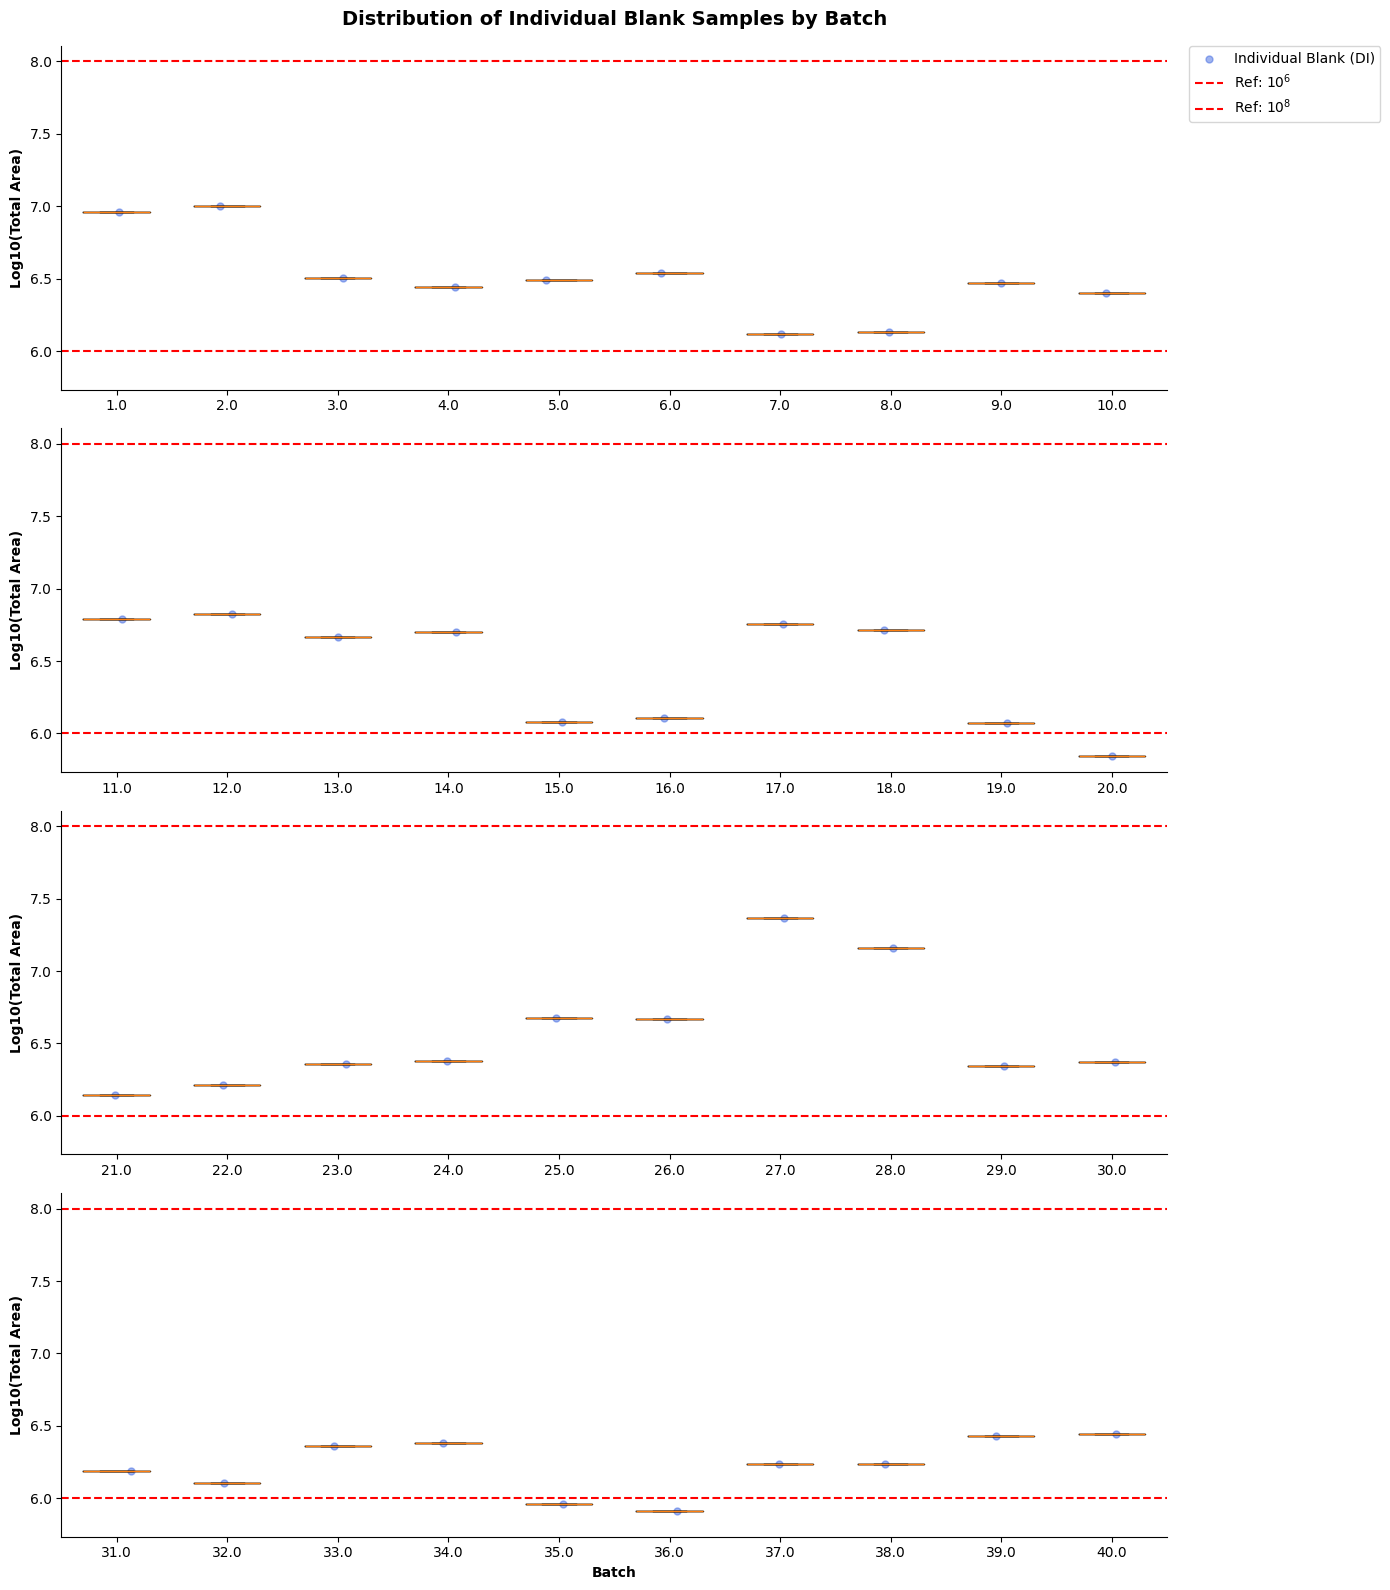

Plot successfully saved to:
/content/gdrive/MyDrive/REVEAL_UCSF_project/First400/per_sample_area_blanks_log10.png



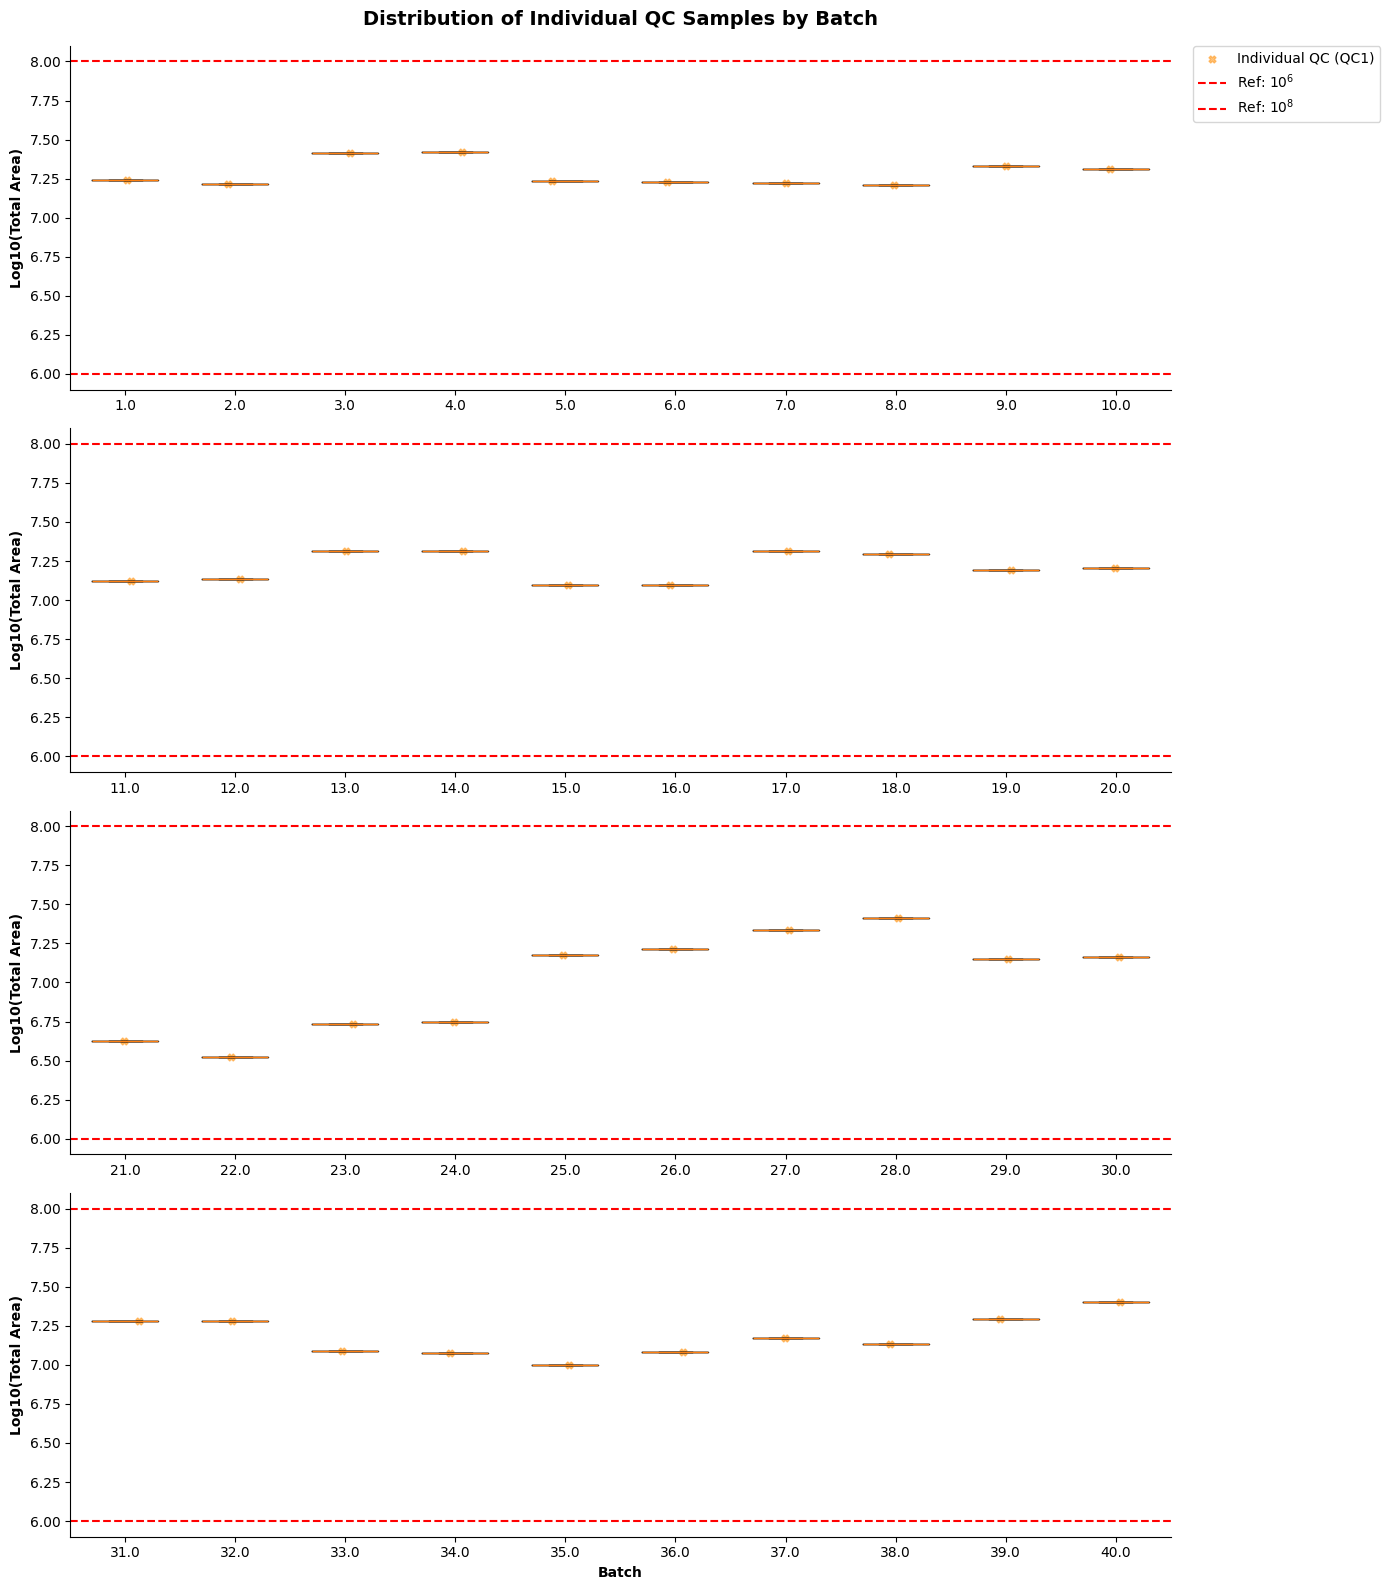

Plot successfully saved to:
/content/gdrive/MyDrive/REVEAL_UCSF_project/First400/per_sample_area_qc_log10.png



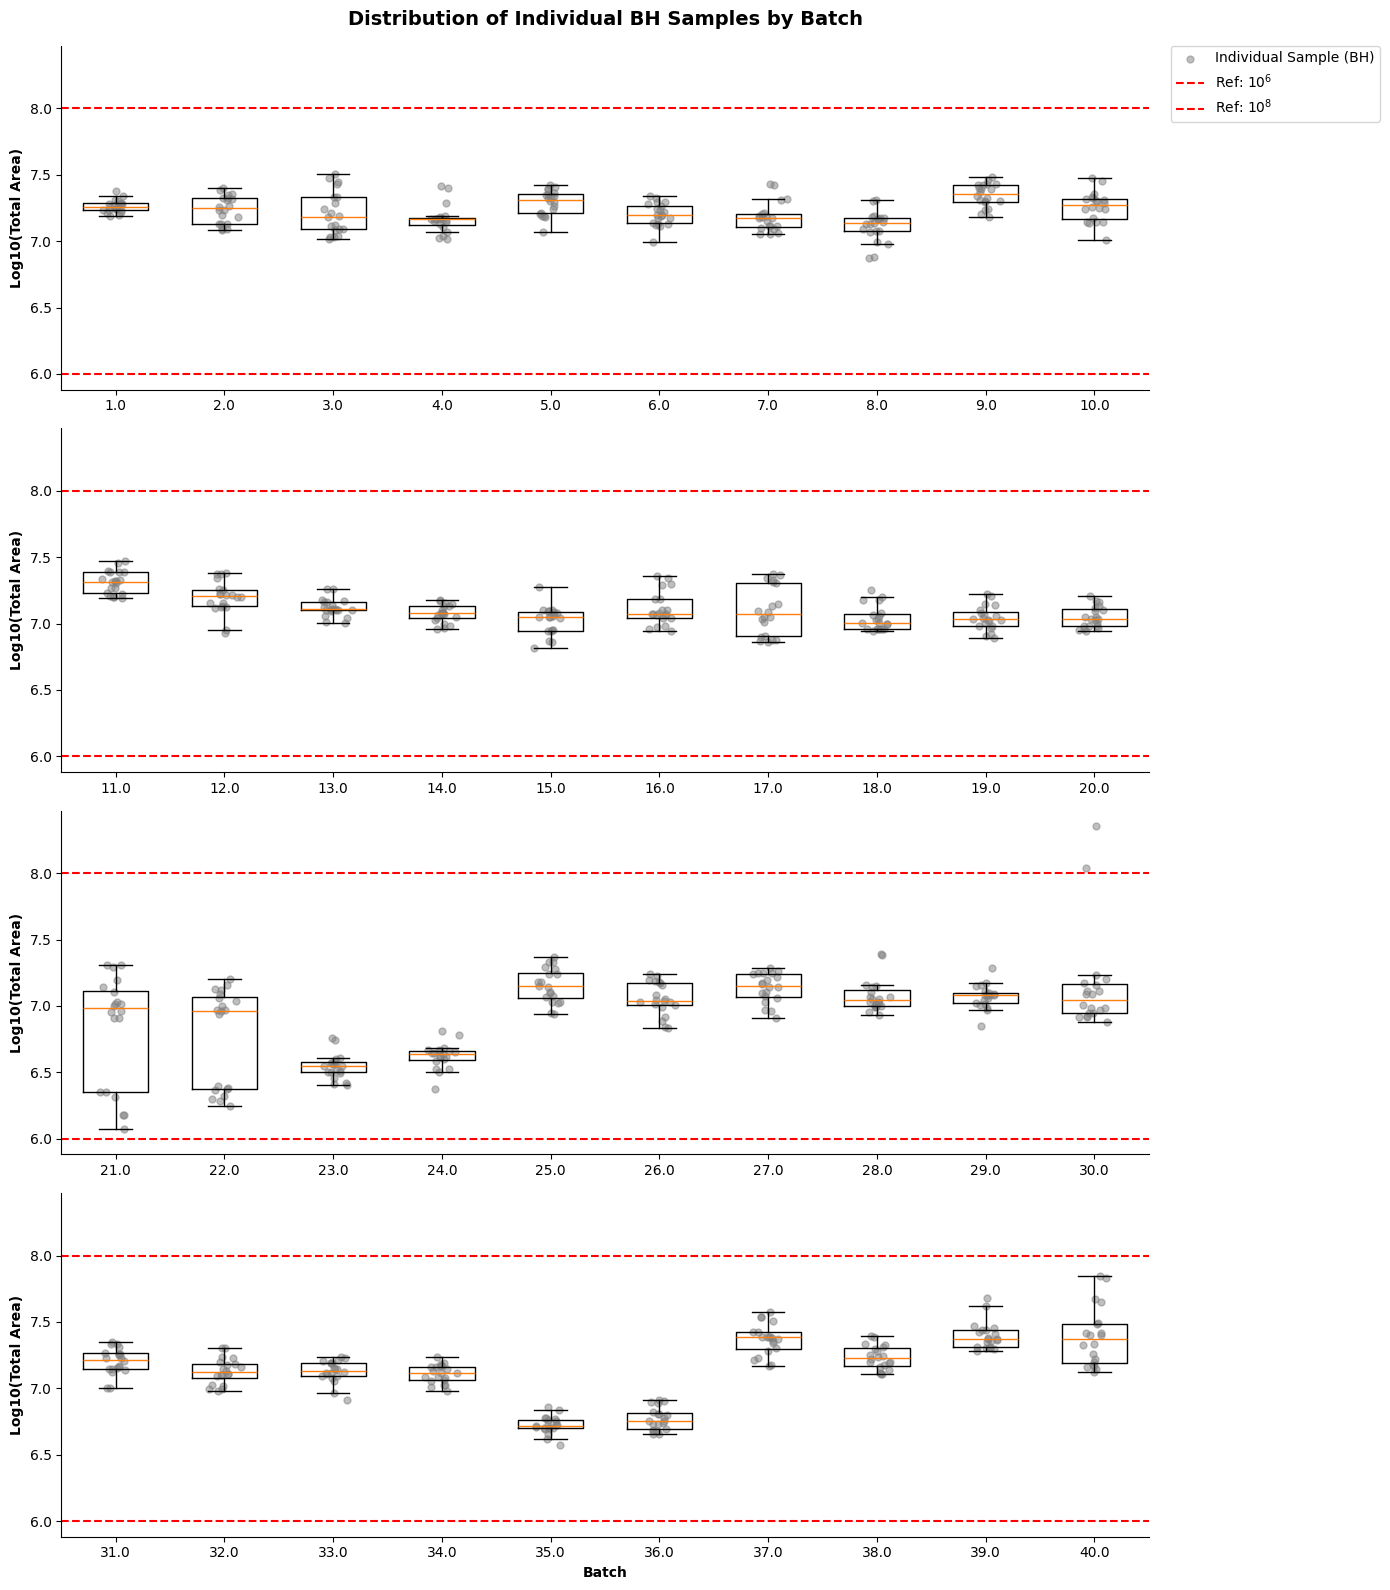

Plot successfully saved to:
/content/gdrive/MyDrive/REVEAL_UCSF_project/First400/per_sample_area_bh_log10.png



In [ ]:
# from google.colab import drive
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import math

# # --------------------------------------------------
# # Step 1: Calculate the Feature Sum for EACH Sample
# # --------------------------------------------------
# sample_sums = corrected_pos_peak_area.sum(axis=0).reset_index()
# sample_sums.columns = ['Sample', 'per_sample_sum_area']

# # Merge with meta_info
# plot_df = pd.merge(sample_sums, meta_info[['Sample', 'Batch']], on='Sample', how='inner')

# plot_df['Sample_Type'] = 'Other'
# plot_df.loc[plot_df['Sample'].str.startswith('BH'), 'Sample_Type'] = 'Sample (BH)'
# plot_df.loc[plot_df['Sample'].str.startswith('DI'), 'Sample_Type'] = 'Blank (DI)'
# plot_df.loc[plot_df['Sample'].str.startswith('QC1'), 'Sample_Type'] = 'QC (QC1)'

# # --- THE FIX: Force strict numeric types to prevent NumPy log10 errors ---
# plot_df['per_sample_sum_area'] = pd.to_numeric(plot_df['per_sample_sum_area'], errors='coerce')

# # Drop any NaNs and ensure values are strictly positive for log-scale plotting
# plot_df = plot_df.dropna(subset=['per_sample_sum_area'])
# plot_df = plot_df[plot_df['per_sample_sum_area'] > 0]

# # Now safely apply the Log10 Transform
# plot_df['log10_area'] = np.log10(plot_df['per_sample_sum_area'].astype(float))

# # --------------------------------------------------
# # Step 2: Reusable Grid Plotting Function
# # --------------------------------------------------
# def build_grid_plot(data, sample_type_label, plot_title, filename, point_color, ref_lines=None, point_marker='o', save_directory=gdrive_path2):

#     if ref_lines is None:
#         ref_lines = []

#     df_sub = data[data['Sample_Type'] == sample_type_label].copy()

#     if df_sub.empty:
#         print(f"Warning: No positive data found for {sample_type_label}. Skipping plot.")
#         return

#     def extract_batch_number(x):
#         import re
#         nums = re.findall(r'\d+', str(x))
#         return int(nums[0]) if nums else np.nan

#     batch_order = (
#         df_sub[['Batch']]
#         .drop_duplicates()
#         .assign(batch_num=lambda df: df['Batch'].apply(extract_batch_number))
#         .sort_values('batch_num')
#         ['Batch']
#         .tolist()
#     )

#     batches_per_row = 10
#     num_rows = math.ceil(len(batch_order) / batches_per_row)

#     fig, axes = plt.subplots(nrows=num_rows, ncols=1, figsize=(14, 4 * num_rows), sharey=True)
#     if num_rows == 1:
#         axes = [axes]

#     rng = np.random.default_rng(42)

#     for i, ax in enumerate(axes):
#         start_idx = i * batches_per_row
#         end_idx = start_idx + batches_per_row
#         current_batches = batch_order[start_idx:end_idx]

#         if not current_batches:
#             ax.set_visible(False)
#             continue

#         # Prepare boxplot data using the LOG10 values
#         plot_data = [
#             df_sub.loc[df_sub['Batch'] == b, 'log10_area'].values
#             for b in current_batches
#         ]
#         x_positions = np.arange(1, len(current_batches) + 1)

#         # Draw boxplots
#         ax.boxplot(plot_data, positions=x_positions, widths=0.6, patch_artist=False, showfliers=False)

#         # Draw individual scatter points using LOG10 values
#         for j, batch_name in enumerate(current_batches, start=1):
#             y = df_sub.loc[df_sub['Batch'] == batch_name, 'log10_area'].values
#             if len(y) > 0:
#                 x = rng.normal(loc=j, scale=0.06, size=len(y))
#                 ax.scatter(x, y, alpha=0.5, s=25, color=point_color, marker=point_marker,
#                            label=f'Individual {sample_type_label}' if i == 0 and j == 1 else "")

#         # Dynamic Reference Lines (Log10 Transformed)
#         for ref_val in ref_lines:
#             log_ref_val = math.log10(ref_val)
#             power = int(log_ref_val)
#             label_str = f'Ref: 10$^{{{power}}}$' if i == 0 else ""
#             ax.axhline(y=log_ref_val, color='red', linestyle='--', linewidth=1.5, label=label_str)

#         # Formatting
#         ax.set_xticks(x_positions)
#         ax.set_xticklabels(current_batches, rotation=0, ha='center')

#         # Labeling
#         if i == num_rows - 1:
#             ax.set_xlabel('Batch', fontweight='bold')
#         ax.set_ylabel('Log10(Total Area)', fontweight='bold')

#         # Top Title & Legend handling
#         if i == 0:
#             ax.set_title(plot_title, fontweight='bold', fontsize=14, pad=15)
#             handles, labels = ax.get_legend_handles_labels()
#             by_label = dict(zip(labels, handles))
#             ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)

#     plt.tight_layout()

#     save_path = os.path.join(save_directory, filename)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

#     print(f'Plot successfully saved to:\n{save_path}\n')

# # --------------------------------------------------
# # Step 3: Execute Plotting
# # --------------------------------------------------

# # 1. Plot Blank Samples (Red lines updated to 1e6 and 1e8)
# build_grid_plot(
#     data=plot_df,
#     sample_type_label='Blank (DI)',
#     plot_title='Distribution of Individual Blank Samples by Batch',
#     filename='per_sample_area_blanks_log10.png',
#     point_color='royalblue',
#     ref_lines=[1e6, 1e8],
#     point_marker='o'
# )

# # 2. Plot QC Samples (Red lines updated to 1e6 and 1e8)
# build_grid_plot(
#     data=plot_df,
#     sample_type_label='QC (QC1)',
#     plot_title='Distribution of Individual QC Samples by Batch',
#     filename='per_sample_area_qc_log10.png',
#     point_color='darkorange',
#     ref_lines=[1e6, 1e8],
#     point_marker='X'
# )

# # 3. Plot BH Samples
# build_grid_plot(
#     data=plot_df,
#     sample_type_label='Sample (BH)',
#     plot_title='Distribution of Individual BH Samples by Batch',
#     filename='per_sample_area_bh_log10.png',
#     point_color='gray',
#     ref_lines=[1e6, 1e8],
#     point_marker='o'
# )

In [ ]:
# # ----------------------------------------
# # Step 1: extract BH sample columns
# # ----------------------------------------
# bh_cols = [col for col in corrected_pos_peak_area.columns if str(col).startswith('BH')]

# if not bh_cols:
#     raise ValueError("No columns starting with 'BH' were found in corrected_pos_peak_area.")

# # ----------------------------------------
# # Step 2: keep annotation columns
# # ----------------------------------------
# annotation_cols = []
# for col in ['DTXSID', 'Alignment ID', 'Average Rt(min)', 'Average Mz']:
#     if col in matched_peak_pos.columns:
#         annotation_cols.append(col)

# if not annotation_cols:
#     print("Warning: no annotation columns found in matched_peak_pos.")

# # ----------------------------------------
# # Step 3: extract BH dataframe and collapse duplicated samples
# # Example: BH001_r1, BH001_r2 -> BH001
# # ----------------------------------------
# bh_df = corrected_pos_peak_area[bh_cols].copy()

# # group duplicated BH columns by sample prefix before "_"
# sample_names = pd.Series([str(c).split('_')[0] for c in bh_df.columns], index=bh_df.columns)

# # row-wise mean for duplicated BH columns
# bh_mean_df = bh_df.T.groupby(sample_names).mean().T

# # ----------------------------------------
# # Step 4: build main result table
# # ----------------------------------------
# result_df = pd.concat(
#     [
#         matched_peak_pos[annotation_cols].reset_index(drop=True),
#         bh_mean_df.reset_index(drop=True)
#     ],
#     axis=1
# )

# # ----------------------------------------
# # Step 5: create feature_id
# # Use current result_df columns to avoid mismatched indexing
# # ----------------------------------------
# if {'Average Mz', 'Average Rt(min)'}.issubset(result_df.columns):
#     result_df['feature_id'] = (
#         result_df['Average Mz'].round(4).astype(str) + '_' +
#         result_df['Average Rt(min)'].round(3).astype(str)
#     )
# else:
#     raise KeyError("Columns 'Average Mz' and/or 'Average Rt(min)' are missing for feature_id creation.")

# # move feature_id to the front
# front_cols = ['feature_id'] + [col for col in result_df.columns if col != 'feature_id']
# result_df = result_df[front_cols].copy()

# # ----------------------------------------
# # Step 6: calculate detection frequency
# # Detection frequency = % of BH samples with peak area >= 1000
# # calculated from the deduplicated BH mean table
# # ----------------------------------------
# bh_mean_cols = list(bh_mean_df.columns)

# result_df['Detection frequency'] = (
#     result_df[bh_mean_cols]
#     .ge(1000)
#     .sum(axis=1)
#     .div(len(bh_mean_cols))
#     .mul(100)
# )

# # ----------------------------------------
# # Optional: reorder columns
# # ----------------------------------------
# meta_cols = [col for col in ['feature_id', 'DTXSID', 'Alignment ID', 'Average Rt(min)', 'Average Mz', 'Detection frequency'] if col in result_df.columns]
# result_df = result_df[meta_cols + bh_mean_cols]

# print(result_df.shape)
# print(tabulate.tabulate(result_df.head(), headers='keys', tablefmt='psql', showindex=False))
# result_df.to_csv(os.path.join(gdrive_path2,"mathced_peaks_QACs_rawmean_intensity_20260418.csv"))

(231, 405)
+----------------+----------------+-------------------+--------------+-----------------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+-----------

In [ ]:
# #find the sample with highest intensity for each feature at each row, and record the highest intensity
# bh_columns = [col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]

# # Find the column name (sample name) with the maximum intensity for each row
# max_intensity_sample = matched_peak_area_df_pos[bh_columns].idxmax(axis=1)
# matched_peak_area_df_pos['max_intensity_sample'] = max_intensity_sample

# # Get the maximum intensity value for each row using the sample name found above
# matched_peak_area_df_pos['max_intensity'] = matched_peak_area_df_pos[bh_columns].max(axis=1)


# #find the sample with second highest intensity for each feature at each row
# # Find the column name (sample name) with the second highest intensity for each row
# second_max_intensity_sample = matched_peak_area_df_pos[bh_columns].T.apply(lambda x: x.nlargest(2).idxmin())
# matched_peak_area_df_pos['second_max_intensity_sample'] = second_max_intensity_sample

# # Get the second highest intensity value for each row using the sample name found above
# second_max_intensity_value = matched_peak_area_df_pos[bh_columns].apply(lambda x: x.nlargest(2).iloc[-1], axis=1)
# matched_peak_area_df_pos['second_max_intensity'] = second_max_intensity_value

# # print(matched_peak_area_df_pos.shape)
# # #make a summary box for the table and extrac column of average mz average rt, matched compound, mean intensity, maximum intensity sample, max_intesnity and second max intesnity,
# summary_stats_df_pos = matched_peak_area_df_pos[['Average Mz', 'Average Rt(min)', 'Matched Compound', 'DTXSID','PREFERRED_NAME','mean_intensity', 'max_intensity_sample', 'max_intensity', 'second_max_intensity_sample', 'second_max_intensity']]
# #write it to csv file
# summary_stats_df_pos.to_csv(os.path.join(gdrive_path2,"mathced_peaks_summary_forallsamples_pos_QACs_formsmsacquisition_20260309.csv"))

In [ ]:
#calculate the detection frequency for the compounds
#heatmap for the QA compounds based on the original peak abundance
  #get the fixed feature id
#summary_stats_df_pos['feature_id'] = combining round the Average mass to 4 digit and round the average (RT) to 4 digit
  #round the Average Mz to 4 digit
# #filter summary dataframe
# matched_peak_area_df_pos['Average Mz'] = matched_peak_area_df_pos['Average Mz'].round(4)
# matched_peak_area_df_pos['Average Rt(min)'] = matched_peak_area_df_pos['Average Rt(min)'].round(4)
# matched_peak_area_df_pos['feature_id'] = matched_peak_area_df_pos['Average Mz'].astype(str) + '_' + matched_peak_area_df_pos['Average Rt(min)'].astype(str)

# #filter columns, retain feature_id and columns starts with BH
# stats_df_DF = matched_peak_area_df_pos[['feature_id']+[col for col in matched_peak_area_df_pos.columns if col.startswith('BH')]]

# #calculate the detection frequency for the matched peaks = number of sample column with peak area >=5000 / total number of sample column, sample column starts with BH
# stats_df_DF['Detection frequency'] = stats_df_DF.iloc[:,1:].apply(lambda x: (x >= 5000).sum() / len(x), axis=1)*100

# #describe the detection frequency stats
# stats_df_DF['Detection frequency'].describe()

/tmp/ipykernel_320/1489384930.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_df_DF['Detection frequency'] = stats_df_DF.iloc[:,1:].apply(lambda x: (x >= 5000).sum() / len(x), axis=1)*100


,Detection frequency
count,231.000000
mean,35.169913
std,29.523067
min,0.000000
25%,6.875000
50%,34.000000
75%,55.625000
max,100.000000
